# Multimodal Random Forest: Linguistic + Acoustic Features

Combines 24 CYMO linguistic features with acoustic features (F0, energy, ZCR, etc.)  
and compares: linguistic only vs acoustic only vs combined.

---

In [1]:
# ╔══════════════════════════════════════════════════════════╗
# ║  PATHS                                                  ║
# ╚══════════════════════════════════════════════════════════╝

# ParkCeleb
PARKCELEB_DIR = '../ParkCeleb'
CYMO_PC       = '../ParkCeleb/ann.cymo_parkceleb_per_recording.csv'
META_PC       = './cymo_parkceleb_per_recording_metadata.csv'
FEAT_CSV      = './mrmr_top10_features.csv'  # your 24 selected CYMO features

# KCL
KCL_DIR       = '../KCL'
CYMO_KCL_RT   = '../KCL/ann.cymo_kcl_readtext_full.csv'
META_KCL_RT   = './cymo_kcl_readtext_full_metadata.csv'
CYMO_KCL_SD   = '../KCL/ann.cymo_kcl_dialogue_full.csv'
META_KCL_SD   = './cymo_kcl_dialogue_full_metadata.csv'

# Pre-computed acoustic features (set to None to extract fresh)
PC_ACOUSTIC_CSV = './parkceleb_acoustic_features.csv'   # e.g. './parkceleb_acoustic.csv' if already extracted
KCL_ACOUSTIC_CSV = './kcl_acoustic.csv'  # e.g. './kcl_audio_features.csv' from notebook 01

In [2]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
import librosa, parselmouth, joblib, os, glob, time, warnings
from scipy import ndimage
warnings.filterwarnings('ignore')
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, f1_score, recall_score,
                             roc_auc_score, confusion_matrix, roc_curve, auc)
plt.rcParams.update({'figure.dpi': 130, 'font.size': 10, 'axes.titleweight': 'bold'})

---
## 1 — Extract acoustic features

In [3]:
# ============================================================
# 1.1  Acoustic feature extraction function
# ============================================================

def extract_acoustic(filepath, target_sr=16000):
    """Extract acoustic features from one audio file. Returns dict or None."""
    try:
        y, sr = librosa.load(filepath, sr=target_sr)
        duration = len(y) / sr
        if duration < 1.0:
            return None

        fl = int(sr * 0.025)
        hl = int(sr * 0.010)

        # RMS energy
        rms = librosa.feature.rms(y=y, frame_length=fl, hop_length=hl)[0]
        rms_db = 20 * np.log10(rms + 1e-10)

        # ZCR
        zcr = librosa.feature.zero_crossing_rate(y, frame_length=fl, hop_length=hl)[0]

        # Spectral centroid
        cent = librosa.feature.spectral_centroid(y=y, sr=sr, hop_length=hl)[0]

        # F0 via Praat
        snd = parselmouth.Sound(y.astype(np.float64), sampling_frequency=sr)
        pitch = snd.to_pitch(time_step=0.01, pitch_floor=75.0, pitch_ceiling=500.0)
        f0 = pitch.selected_array['frequency']
        f0_voiced = f0[f0 > 0]

        # Intensity via Praat
        intensity = snd.to_intensity(time_step=0.01, minimum_pitch=75.0)
        int_vals = intensity.values[0]

        # VAD-based speech fraction
        sorted_rms = np.sort(rms_db)
        noise_floor = np.median(sorted_rms[:max(1, len(sorted_rms)//10)])
        vad = (rms_db >= noise_floor + 15).astype(float)
        vad = ndimage.median_filter(vad, size=5)
        speech_frac = vad.mean()

        feats = {
            'duration_s': duration,
            'rms_mean': rms.mean(),
            'rms_std': rms.std(),
            'rms_db_mean': rms_db.mean(),
            'rms_db_std': rms_db.std(),
            'zcr_mean': zcr.mean(),
            'zcr_std': zcr.std(),
            'centroid_mean': cent.mean(),
            'centroid_std': cent.std(),
            'f0_mean': f0_voiced.mean() if len(f0_voiced) > 0 else np.nan,
            'f0_std': f0_voiced.std() if len(f0_voiced) > 0 else np.nan,
            'f0_range': (f0_voiced.max() - f0_voiced.min()) if len(f0_voiced) > 1 else np.nan,
            'voicing_frac': len(f0_voiced) / len(f0) if len(f0) > 0 else np.nan,
            'intensity_mean': int_vals.mean(),
            'intensity_std': int_vals.std(),
            'speech_frac': speech_frac,
        }
        return feats
    except Exception as e:
        return None

In [4]:
# ============================================================
# 1.2  Extract ParkCeleb acoustic features (or load from CSV)
# ============================================================
if PC_ACOUSTIC_CSV and os.path.isfile(PC_ACOUSTIC_CSV):
    pc_acoustic = pd.read_csv(PC_ACOUSTIC_CSV)
    print(f'Loaded ParkCeleb acoustic features: {len(pc_acoustic)} rows')
else:
    print('Extracting ParkCeleb acoustic features...')
    print('(This runs once and saves to CSV. ~2-5 min per 100 files)\n')
    
    rows = []
    count = 0
    for group in ['CN', 'PD']:
        group_dir = os.path.join(PARKCELEB_DIR, group)
        if not os.path.isdir(group_dir): continue
        for subj in sorted(os.listdir(group_dir)):
            subj_dir = os.path.join(group_dir, subj)
            if not os.path.isdir(subj_dir): continue
            for vid_id in sorted(os.listdir(subj_dir)):
                vid_dir = os.path.join(subj_dir, vid_id)
                if not os.path.isdir(vid_dir): continue
                # Find audio file
                audio_files = [f for f in os.listdir(vid_dir)
                               if f.endswith(('.wav','.mp3','.flac','.m4a'))]
                if not audio_files: continue
                
                fpath = os.path.join(vid_dir, audio_files[0])
                feats = extract_acoustic(fpath)
                if feats:
                    feats['group'] = group
                    feats['subject'] = subj
                    feats['video_id'] = vid_id
                    rows.append(feats)
                
                count += 1
                if count % 100 == 0:
                    print(f'  {count} files processed...')
    
    pc_acoustic = pd.DataFrame(rows)
    pc_acoustic.to_csv('parkceleb_acoustic.csv', index=False)
    print(f'\nDone: {len(pc_acoustic)} files. Saved to parkceleb_acoustic.csv')
    PC_ACOUSTIC_CSV = 'parkceleb_acoustic.csv'

Loaded ParkCeleb acoustic features: 298 rows


In [5]:
# ============================================================
# 1.3  Extract KCL acoustic features (or load from CSV)
# ============================================================
if KCL_ACOUSTIC_CSV and os.path.isfile(KCL_ACOUSTIC_CSV):
    kcl_acoustic = pd.read_csv(KCL_ACOUSTIC_CSV)
    print(f'Loaded KCL acoustic features: {len(kcl_acoustic)} rows')
else:
    print('Extracting KCL acoustic features...')
    rows = []
    for task in ['ReadText', 'SpontaneousDialogue']:
        for group_folder in ['HC', 'PD']:
            folder = os.path.join(KCL_DIR, task, group_folder)
            if not os.path.isdir(folder): continue
            group_label = 'CN' if group_folder == 'HC' else 'PD'
            for f in sorted(os.listdir(folder)):
                if not f.endswith('.wav'): continue
                fpath = os.path.join(folder, f)
                feats = extract_acoustic(fpath)
                if feats:
                    name = os.path.splitext(f)[0]
                    parts = name.split('_')
                    feats['group'] = group_label
                    feats['subject'] = parts[0] if parts else name
                    feats['task'] = task
                    feats['filename'] = f
                    rows.append(feats)
    
    kcl_acoustic = pd.DataFrame(rows)
    kcl_acoustic.to_csv('kcl_acoustic.csv', index=False)
    print(f'Done: {len(kcl_acoustic)} files. Saved to kcl_acoustic.csv')
    KCL_ACOUSTIC_CSV = 'kcl_acoustic.csv'

Loaded KCL acoustic features: 73 rows


---
## 2 — Build combined feature sets

In [6]:
# ============================================================
# 2.1  Aggregate acoustic features to subject level
# ============================================================
acoustic_cols = [
                 'f0_std', 'f0_range', 'speech_frac']

# ParkCeleb: aggregate per subject
pc_ac_subj = pc_acoustic.groupby('subject').agg(
    {**{c: 'mean' for c in acoustic_cols}, 'group': 'first'}
).reset_index()
pc_ac_subj['label'] = (pc_ac_subj['group'] == 'PD').astype(int)
# Prefix acoustic columns to avoid name clashes with CYMO
pc_ac_subj = pc_ac_subj.rename(columns={c: f'ac_{c}' for c in acoustic_cols})
ac_feat_cols = [f'ac_{c}' for c in acoustic_cols]

print(f'ParkCeleb acoustic (subject level): {len(pc_ac_subj)} subjects, {len(ac_feat_cols)} features')

# KCL: aggregate per subject (across tasks)
kcl_ac_subj = kcl_acoustic.groupby('subject').agg(
    {**{c: 'mean' for c in acoustic_cols}, 'group': 'first'}
).reset_index()
kcl_ac_subj['label'] = (kcl_ac_subj['group'] == 'PD').astype(int)
kcl_ac_subj = kcl_ac_subj.rename(columns={c: f'ac_{c}' for c in acoustic_cols})

print(f'KCL acoustic (subject level): {len(kcl_ac_subj)} subjects')

ParkCeleb acoustic (subject level): 100 subjects, 3 features
KCL acoustic (subject level): 38 subjects


In [7]:
# ============================================================
# 2.2  Load CYMO linguistic features, aggregate to subject level
# ============================================================
cymo = pd.read_csv(CYMO_PC)
meta = pd.read_csv(META_PC)
ling_features = pd.read_csv(FEAT_CSV)['feature'].tolist()

tid_col = 'TID' if 'TID' in cymo.columns else cymo.columns[0]
meta_tid = 'TID' if 'TID' in meta.columns else meta.columns[0]

pc_ling = cymo.merge(meta[[meta_tid, 'group', 'subject']].drop_duplicates(),
                     left_on=tid_col, right_on=meta_tid, how='inner')
pc_ling['label'] = (pc_ling['group'] == 'PD').astype(int)
for col in ling_features:
    pc_ling[col] = pd.to_numeric(pc_ling.get(col, 0), errors='coerce')

# Aggregate to subject level (mean only for cross-corpus compatibility)
pc_ling_subj = pc_ling.groupby('subject').agg(
    {**{f: 'mean' for f in ling_features}, 'label': 'first'}
).reset_index()

print(f'ParkCeleb linguistic (subject level): {len(pc_ling_subj)} subjects, {len(ling_features)} features')

# Same for KCL
kcl_ling_dfs = []
for cymo_path, meta_path in [(CYMO_KCL_RT, META_KCL_RT), (CYMO_KCL_SD, META_KCL_SD)]:
    try:
        c = pd.read_csv(cymo_path)
        m = pd.read_csv(meta_path)
        tc = 'TID' if 'TID' in c.columns else c.columns[0]
        mc = 'TID' if 'TID' in m.columns else m.columns[0]
        sc = next((x for x in m.columns if x in ('subject', 'subject_id')), None)
        merged = c.merge(m[[mc, 'group', sc]].drop_duplicates(), left_on=tc, right_on=mc, how='inner')
        if sc != 'subject': merged = merged.rename(columns={sc: 'subject'})
        merged['label'] = (merged['group'] == 'PD').astype(int)
        kcl_ling_dfs.append(merged)
    except FileNotFoundError:
        pass

if kcl_ling_dfs:
    kcl_ling = pd.concat(kcl_ling_dfs, ignore_index=True)
    for col in ling_features:
        kcl_ling[col] = pd.to_numeric(kcl_ling.get(col, 0), errors='coerce')
    kcl_ling_subj = kcl_ling.groupby('subject').agg(
        {**{f: 'mean' for f in ling_features}, 'label': 'first'}
    ).reset_index()
    print(f'KCL linguistic (subject level): {len(kcl_ling_subj)} subjects')
else:
    kcl_ling_subj = None
    print('KCL linguistic: not available')

ParkCeleb linguistic (subject level): 100 subjects, 24 features
KCL linguistic (subject level): 38 subjects


In [8]:
# ============================================================
# 2.3  Merge linguistic + acoustic for each dataset
# ============================================================

# ParkCeleb combined
pc_combined = pc_ling_subj.merge(pc_ac_subj[['subject'] + ac_feat_cols],
                                 on='subject', how='inner')
pc_combined[ling_features + ac_feat_cols] = pc_combined[ling_features + ac_feat_cols].fillna(
    pc_combined[ling_features + ac_feat_cols].median())

combined_feats = ling_features + ac_feat_cols

print(f'ParkCeleb combined: {len(pc_combined)} subjects, {len(combined_feats)} features')
print(f'  Linguistic: {len(ling_features)}  |  Acoustic: {len(ac_feat_cols)}  |  Total: {len(combined_feats)}')

# KCL combined
if kcl_ling_subj is not None:
    kcl_combined = kcl_ling_subj.merge(kcl_ac_subj[['subject'] + ac_feat_cols],
                                       on='subject', how='inner')
    kcl_combined[ling_features + ac_feat_cols] = kcl_combined[ling_features + ac_feat_cols].fillna(0)
    print(f'KCL combined: {len(kcl_combined)} subjects')
else:
    kcl_combined = None

ParkCeleb combined: 100 subjects, 27 features
  Linguistic: 24  |  Acoustic: 3  |  Total: 27
KCL combined: 38 subjects


---
## 3 — Compare: Linguistic vs Acoustic vs Combined

In [9]:
# ============================================================
# 3.  Cross-validated grid search (same approach as notebook 11)
# ============================================================
from sklearn.model_selection import StratifiedGroupKFold

# ---- 70/30 subject split (same seed as notebook 11) ----
np.random.seed(42)
cn_s = pc_combined[pc_combined['label']==0].sample(frac=1, random_state=42)
pd_s = pc_combined[pc_combined['label']==1].sample(frac=1, random_state=42)
cs, ps = int(len(cn_s)*0.7), int(len(pd_s)*0.7)

train_subj = pd.concat([cn_s.iloc[:cs], pd_s.iloc[:ps]])
test_subj = pd.concat([cn_s.iloc[cs:], pd_s.iloc[ps:]])

assert len(set(train_subj['subject']) & set(test_subj['subject'])) == 0

for name, sdf in [('Train', train_subj), ('Test', test_subj)]:
    cn_n = (sdf['label']==0).sum()
    pd_n = (sdf['label']==1).sum()
    print(f'{name:>5s}: {len(sdf)} subjects ({cn_n} CN + {pd_n} PD)')
print('✓ No subject leakage.\n')

# ---- Run grid search for each modality ----
param_grid = [
    {'n_estimators': 100, 'max_depth': 3,    'min_samples_leaf': 3, 'max_features': 'sqrt'},
    {'n_estimators': 100, 'max_depth': 5,    'min_samples_leaf': 3, 'max_features': 'sqrt'},
    {'n_estimators': 100, 'max_depth': 5,    'min_samples_leaf': 5, 'max_features': 'sqrt'},
    {'n_estimators': 200, 'max_depth': 3,    'min_samples_leaf': 3, 'max_features': 'sqrt'},
    {'n_estimators': 200, 'max_depth': 5,    'min_samples_leaf': 3, 'max_features': 'sqrt'},
    {'n_estimators': 200, 'max_depth': 5,    'min_samples_leaf': 5, 'max_features': 'sqrt'},
    {'n_estimators': 200, 'max_depth': 10,   'min_samples_leaf': 3, 'max_features': 'sqrt'},
    {'n_estimators': 200, 'max_depth': 5,    'min_samples_leaf': 3, 'max_features': 'log2'},
    {'n_estimators': 200, 'max_depth': 5,    'min_samples_leaf': 3, 'max_features': None},
    {'n_estimators': 500, 'max_depth': 3,    'min_samples_leaf': 3, 'max_features': 'sqrt'},
    {'n_estimators': 500, 'max_depth': 5,    'min_samples_leaf': 3, 'max_features': 'sqrt'},
    {'n_estimators': 500, 'max_depth': 5,    'min_samples_leaf': 5, 'max_features': 'sqrt'},
]

cv = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)

modalities = {
    'Linguistic': ling_features,
    'Acoustic': ac_feat_cols,
    'Combined': combined_feats,
}

all_cv_results = {}

for mod_name, feat_list in modalities.items():
    print(f'Grid search: {mod_name} ({len(feat_list)} features)')
    
    scaler = StandardScaler()
    X_tr = scaler.fit_transform(train_subj[feat_list].fillna(0).values)
    X_te = scaler.transform(test_subj[feat_list].fillna(0).values)
    y_tr = train_subj['label'].values
    y_te = test_subj['label'].values
    groups = train_subj['subject'].values
    
    best_cv_auc, best_params = 0, {}
    grid_results = []
    
    for params in param_grid:
        fold_aucs = []
        for fold, (tr_idx, va_idx) in enumerate(cv.split(X_tr, y_tr, groups)):
            rf = RandomForestClassifier(**params, class_weight='balanced',
                                        random_state=42, n_jobs=-1)
            rf.fit(X_tr[tr_idx], y_tr[tr_idx])
            
            va_prob = rf.predict_proba(X_tr[va_idx])[:, 1]
            va_labels = y_tr[va_idx]
            if len(np.unique(va_labels)) > 1:
                fold_aucs.append(roc_auc_score(va_labels, va_prob))
        
        mean_auc = np.mean(fold_aucs) if fold_aucs else 0
        grid_results.append({**params, 'cv_auc': mean_auc})
        if mean_auc > best_cv_auc:
            best_cv_auc, best_params = mean_auc, params
    
    # Train final model on all training subjects
    final_rf = RandomForestClassifier(**best_params, class_weight='balanced',
                                      random_state=42, n_jobs=-1)
    final_rf.fit(X_tr, y_tr)
    
    # Test evaluation
    y_pred = final_rf.predict(X_te)
    y_prob = final_rf.predict_proba(X_te)[:, 1]
    test_acc = accuracy_score(y_te, y_pred)
    test_auc = roc_auc_score(y_te, y_prob) if len(np.unique(y_te)) > 1 else 0.5
    test_f1 = f1_score(y_te, y_pred, zero_division=0)
    test_sens = recall_score(y_te, y_pred, zero_division=0)
    test_spec = recall_score(y_te, y_pred, pos_label=0, zero_division=0)
    train_acc = accuracy_score(y_tr, final_rf.predict(X_tr))
    
    d = best_params['max_depth']
    d_str = str(d) if d else 'None'
    print(f'  Best: n={best_params["n_estimators"]} d={d_str} '
          f'ml={best_params["min_samples_leaf"]} mf={best_params["max_features"]}  '
          f'CV AUC={best_cv_auc:.3f}')
    print(f'  Train Acc={train_acc:.3f}  Test Acc={test_acc:.3f}  '
          f'Test AUC={test_auc:.3f}  F1={test_f1:.3f}\n')
    
    all_cv_results[mod_name] = {
        'model': final_rf, 'scaler': scaler, 'features': feat_list,
        'params': best_params, 'cv_auc': best_cv_auc,
        'train_acc': train_acc, 'test_acc': test_acc,
        'test_auc': test_auc, 'test_f1': test_f1,
        'test_sens': test_sens, 'test_spec': test_spec,
    }

# Summary
print('SUMMARY')
print('=' * 80)
print(f'{"Modality":<15s} {"#Feat":>6s} {"Best Params":<35s} {"CV AUC":>7s} '
      f'{"Tr Acc":>7s} {"Te Acc":>7s} {"Te AUC":>7s}')
print('─' * 80)
for mod_name, r in all_cv_results.items():
    p = r['params']
    d = str(p['max_depth']) if p['max_depth'] else 'None'
    ps = f"n={p['n_estimators']} d={d} ml={p['min_samples_leaf']} mf={p['max_features']}"
    print(f'{mod_name:<15s} {len(r["features"]):>6d} {ps:<35s} {r["cv_auc"]:>7.3f} '
          f'{r["train_acc"]:>7.3f} {r["test_acc"]:>7.3f} {r["test_auc"]:>7.3f}')

Train: 70 subjects (42 CN + 28 PD)
 Test: 30 subjects (18 CN + 12 PD)
✓ No subject leakage.

Grid search: Linguistic (24 features)
  Best: n=500 d=3 ml=3 mf=sqrt  CV AUC=0.817
  Train Acc=0.929  Test Acc=0.867  Test AUC=0.935  F1=0.833

Grid search: Acoustic (3 features)
  Best: n=100 d=5 ml=5 mf=sqrt  CV AUC=0.715
  Train Acc=0.857  Test Acc=0.733  Test AUC=0.806  F1=0.667

Grid search: Combined (27 features)
  Best: n=100 d=5 ml=5 mf=sqrt  CV AUC=0.834
  Train Acc=0.900  Test Acc=0.867  Test AUC=0.903  F1=0.833

SUMMARY
Modality         #Feat Best Params                          CV AUC  Tr Acc  Te Acc  Te AUC
────────────────────────────────────────────────────────────────────────────────
Linguistic          24 n=500 d=3 ml=3 mf=sqrt                0.817   0.929   0.867   0.935
Acoustic             3 n=100 d=5 ml=5 mf=sqrt                0.715   0.857   0.733   0.806
Combined            27 n=100 d=5 ml=5 mf=sqrt                0.834   0.900   0.867   0.903


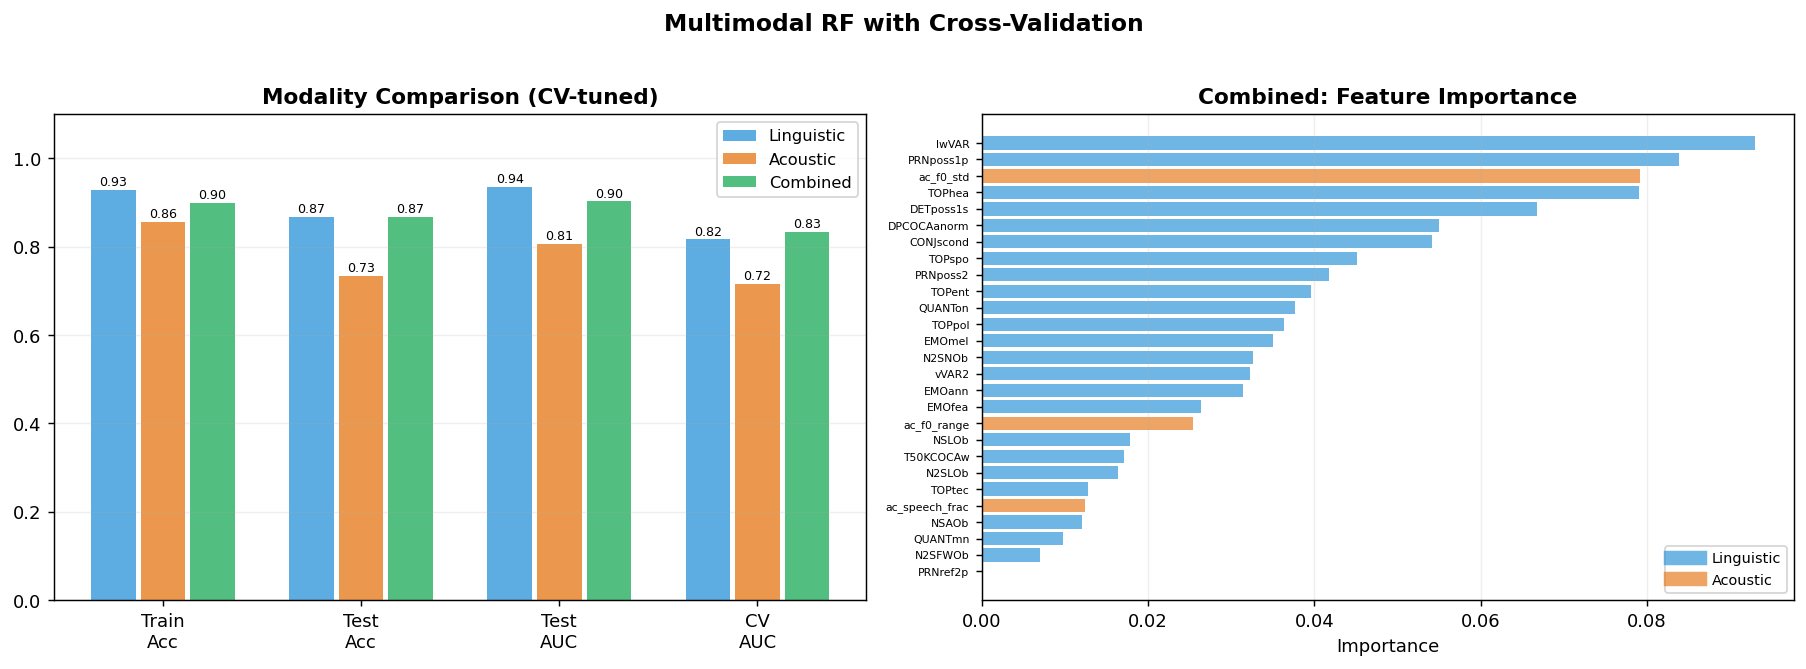

In [10]:
# ============================================================
# 3.3  Comparison visual
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors = {'Linguistic': '#3498DB', 'Acoustic': '#E67E22', 'Combined': '#27AE60'}

# Bar chart
ax = axes[0]
metrics = ['train_acc', 'test_acc', 'test_auc', 'cv_auc']
m_labels = ['Train\nAcc', 'Test\nAcc', 'Test\nAUC', 'CV\nAUC']
x = np.arange(len(metrics))
w = 0.25
for i, (mod, color) in enumerate(colors.items()):
    if mod not in all_cv_results: continue
    r = all_cv_results[mod]
    vals = [r[m] for m in metrics]
    bars = ax.bar(x + i*w - w, vals, w*0.9, label=mod, color=color, alpha=0.8)
    for bar in bars:
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
                f'{bar.get_height():.2f}', ha='center', fontsize=7)
ax.set_xticks(x); ax.set_xticklabels(m_labels)
ax.set_ylim(0, 1.1); ax.legend(fontsize=9); ax.grid(axis='y', alpha=0.2)
ax.set_title('Modality Comparison (CV-tuned)')

# Feature importance for combined model
ax = axes[1]
if 'Combined' in all_cv_results:
    r = all_cv_results['Combined']
    imp = r['model'].feature_importances_
    idx = np.argsort(imp)[::-1]
    bar_colors = ['#3498DB' if r['features'][i] in ling_features else '#E67E22' for i in idx]
    ax.barh(range(len(idx)), imp[idx], color=bar_colors, alpha=0.7)
    ax.set_yticks(range(len(idx)))
    ax.set_yticklabels([r['features'][i] for i in idx], fontsize=6)
    ax.set_xlabel('Importance'); ax.set_title('Combined: Feature Importance')
    ax.invert_yaxis(); ax.grid(axis='x', alpha=0.2)
    ling_p = plt.Line2D([0],[0], color='#3498DB', lw=8, alpha=0.7, label='Linguistic')
    ac_p = plt.Line2D([0],[0], color='#E67E22', lw=8, alpha=0.7, label='Acoustic')
    ax.legend(handles=[ling_p, ac_p], loc='lower right', fontsize=8)

plt.suptitle('Multimodal RF with Cross-Validation', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout(); plt.savefig('multimodal_cv_comparison.png', dpi=150, bbox_inches='tight'); plt.show()

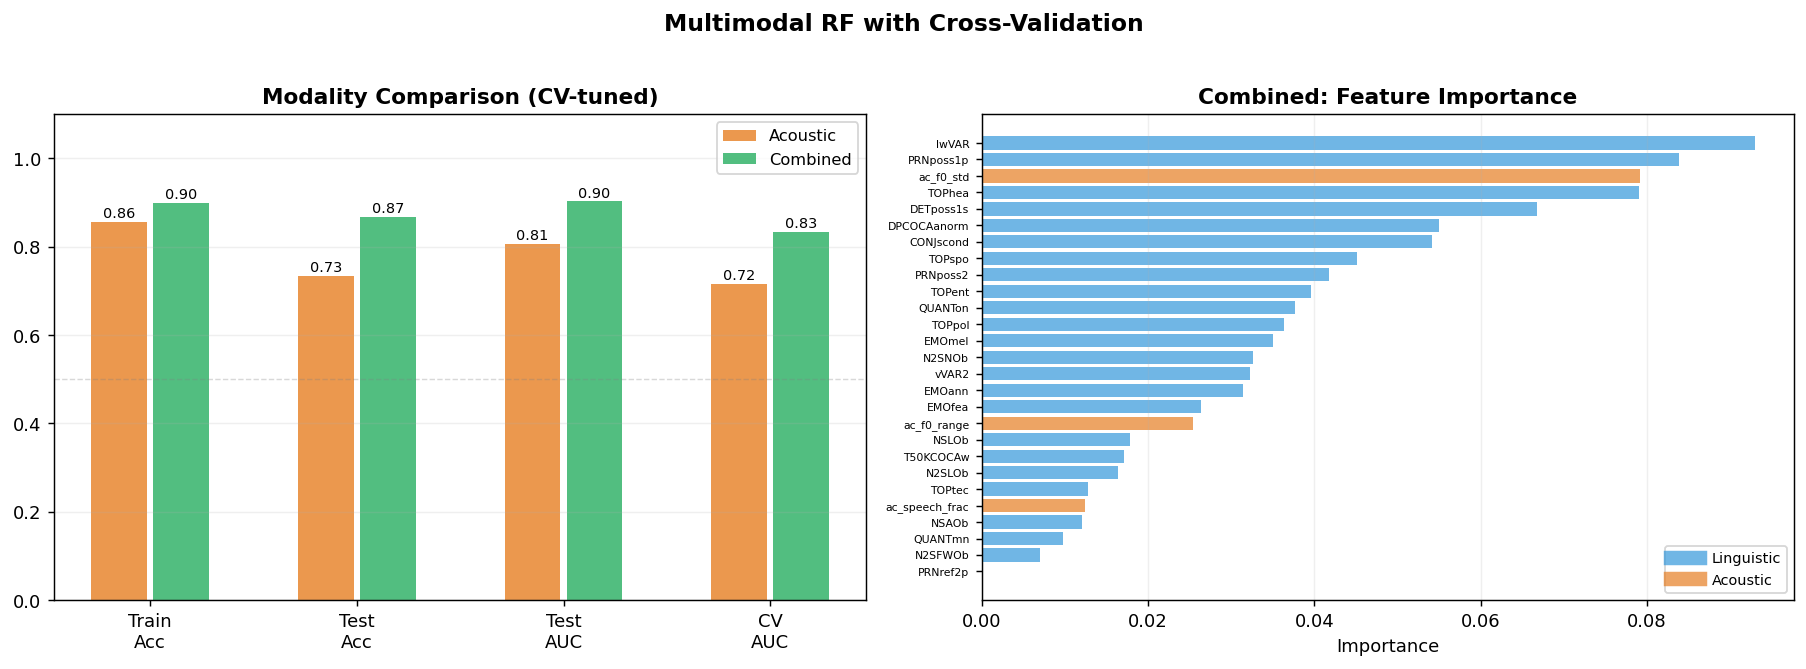

In [11]:
# ============================================================
# 3.4  Visualisation
# ============================================================
colors = {'Acoustic': '#E67E22', 'Combined': '#27AE60'}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart: train acc, test acc, test auc, cv auc for each modality
ax = axes[0]
metrics = ['train_acc', 'test_acc', 'test_auc', 'cv_auc']
m_labels = ['Train\nAcc', 'Test\nAcc', 'Test\nAUC', 'CV\nAUC']
x = np.arange(len(metrics))
w = 0.3
for i, (mod, color) in enumerate(colors.items()):
    if mod not in all_cv_results: continue
    r = all_cv_results[mod]
    vals = [r[m] for m in metrics]
    bars = ax.bar(x + i*w - w/2, vals, w*0.9, label=mod, color=color, alpha=0.8)
    for bar in bars:
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
                f'{bar.get_height():.2f}', ha='center', fontsize=8)
ax.set_xticks(x); ax.set_xticklabels(m_labels)
ax.set_ylim(0, 1.1); ax.legend(fontsize=9); ax.grid(axis='y', alpha=0.2)
ax.axhline(0.5, color='gray', ls='--', lw=0.8, alpha=0.3)
ax.set_title('Modality Comparison (CV-tuned)')

# Feature importance for combined model
ax = axes[1]
if 'Combined' in all_cv_results:
    r = all_cv_results['Combined']
    imp = r['model'].feature_importances_
    idx = np.argsort(imp)[::-1]
    bar_colors = ['#3498DB' if r['features'][i] in ling_features else '#E67E22' for i in idx]
    ax.barh(range(len(idx)), imp[idx], color=bar_colors, alpha=0.7)
    ax.set_yticks(range(len(idx)))
    ax.set_yticklabels([r['features'][i] for i in idx], fontsize=6)
    ax.set_xlabel('Importance'); ax.set_title('Combined: Feature Importance')
    ax.invert_yaxis(); ax.grid(axis='x', alpha=0.2)
    ling_p = plt.Line2D([0],[0], color='#3498DB', lw=8, alpha=0.7, label='Linguistic')
    ac_p = plt.Line2D([0],[0], color='#E67E22', lw=8, alpha=0.7, label='Acoustic')
    ax.legend(handles=[ling_p, ac_p], loc='lower right', fontsize=8)

plt.suptitle('Multimodal RF with Cross-Validation', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout(); plt.savefig('multimodal_cv_comparison.png', dpi=150, bbox_inches='tight'); plt.show()

In [12]:
# ============================================================
# 3.5  Summary table
# ============================================================
print(f'{"Modality":<15s} {"#Feat":>6s} {"CV AUC":>8s} {"Train":>7s} {"Test":>7s} '
      f'{"AUC":>7s} {"Sens":>7s} {"Spec":>7s}')
print('─' * 65)
for mod, r in all_cv_results.items():
    print(f'{mod:<15s} {len(r["features"]):>6d} {r["cv_auc"]:>8.3f} {r["train_acc"]:>7.3f} '
          f'{r["test_acc"]:>7.3f} {r["test_auc"]:>7.3f} {r["test_sens"]:>7.3f} {r["test_spec"]:>7.3f}')

Modality         #Feat   CV AUC   Train    Test     AUC    Sens    Spec
─────────────────────────────────────────────────────────────────
Linguistic          24    0.817   0.929   0.867   0.935   0.833   0.889
Acoustic             3    0.715   0.857   0.733   0.806   0.667   0.778
Combined            27    0.834   0.900   0.867   0.903   0.833   0.889


---
## 4 — Train and save the best model

In [13]:
# ============================================================
# 4.1  Save the best modality model
# ============================================================
#best_mod = max(all_cv_results.keys(), key=lambda k: all_cv_results[k]['test_auc'])
best_mod = 'Combined'
best = all_cv_results[best_mod]

print(f'Best modality: {best_mod}')
print(f'  Features : {len(best["features"])}')
print(f'  Params   : {best["params"]}')
print(f'  CV AUC   : {best["cv_auc"]:.3f}')
print(f'  Train Acc: {best["train_acc"]:.3f}')
print(f'  Test Acc : {best["test_acc"]:.3f}')
print(f'  Test AUC : {best["test_auc"]:.3f}')

joblib.dump({
    'model': best['model'],
    'scaler': best['scaler'],
    'features': best['features'],
    'ling_features': ling_features,
    'acoustic_features': ac_feat_cols,
    'modality': best_mod,
    'params': best['params'],
    'cv_auc': best['cv_auc'],
}, 'rf_multimodal.joblib')
print(f'\nSaved: rf_multimodal.joblib')

Best modality: Combined
  Features : 27
  Params   : {'n_estimators': 100, 'max_depth': 5, 'min_samples_leaf': 5, 'max_features': 'sqrt'}
  CV AUC   : 0.834
  Train Acc: 0.900
  Test Acc : 0.867
  Test AUC : 0.903

Saved: rf_multimodal.joblib


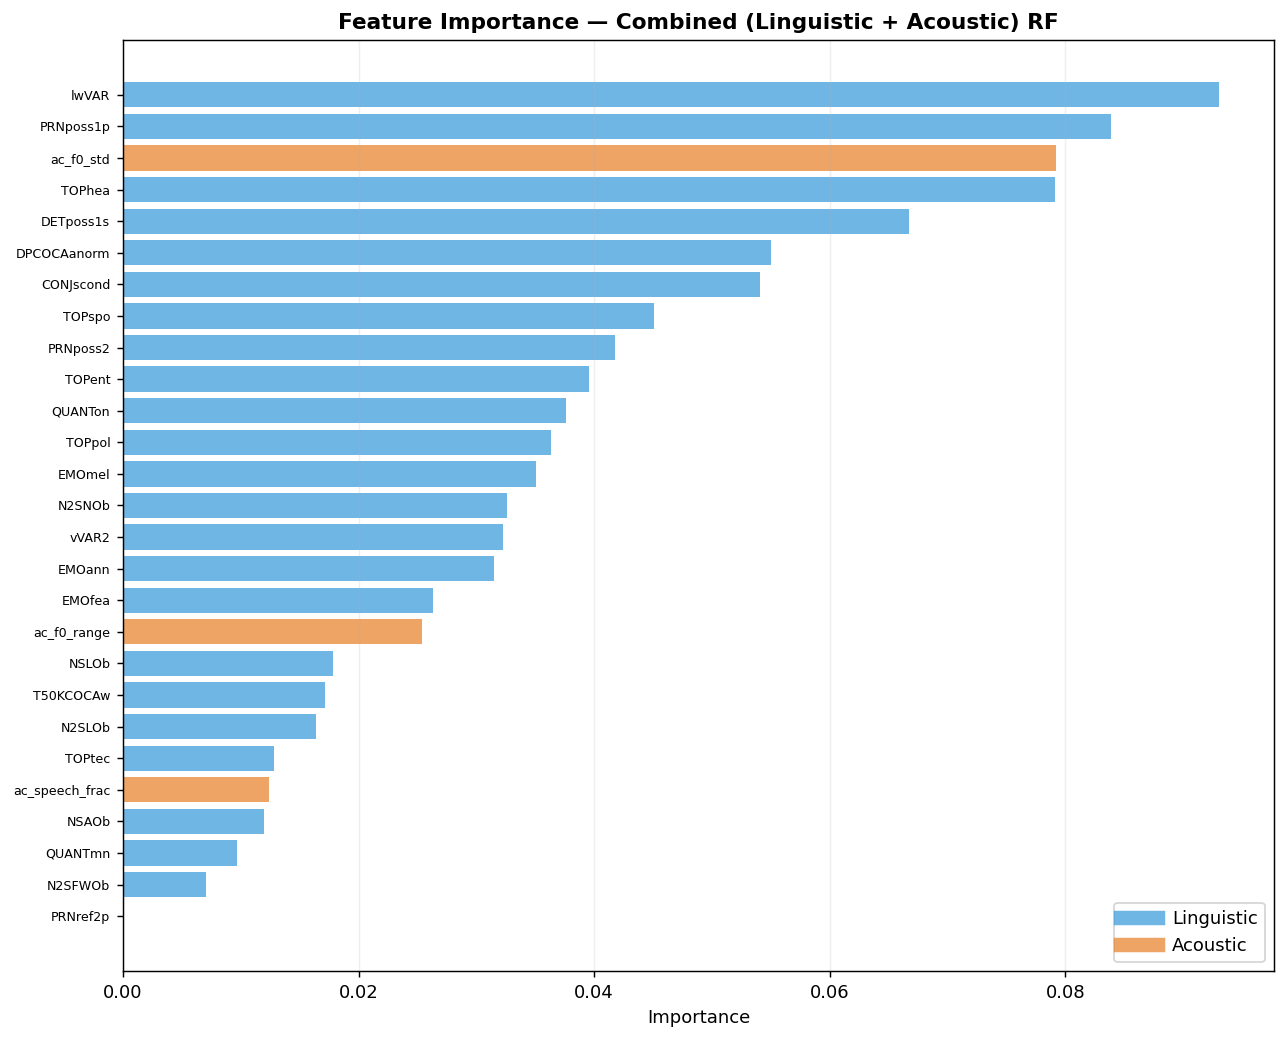


Rank  Feature                              Importance Type        
─────────────────────────────────────────────────────────────────
1     lwVAR                                    0.0931 Linguistic  
2     PRNposs1p                                0.0838 Linguistic  
3     ac_f0_std                                0.0792 Acoustic    
4     TOPhea                                   0.0791 Linguistic  
5     DETposs1s                                0.0667 Linguistic  
6     DPCOCAanorm                              0.0550 Linguistic  
7     CONJscond                                0.0541 Linguistic  
8     TOPspo                                   0.0451 Linguistic  
9     PRNposs2                                 0.0418 Linguistic  
10    TOPent                                   0.0396 Linguistic  
11    QUANTon                                  0.0376 Linguistic  
12    TOPpol                                   0.0364 Linguistic  
13    EMOmel                                   0.0351 Linguist

In [14]:
# ============================================================
# 4.2  Feature importance of the Combined model
# ============================================================
if 'Combined' in all_cv_results:
    r = all_cv_results['Combined']
    imp = r['model'].feature_importances_
    feats = r['features']
    idx = np.argsort(imp)[::-1]

    fig, ax = plt.subplots(figsize=(10, max(5, len(feats)*0.3)))
    bar_colors = ['#3498DB' if feats[i] in ling_features else '#E67E22' for i in idx]
    ax.barh(range(len(idx)), imp[idx], color=bar_colors, alpha=0.7)
    ax.set_yticks(range(len(idx)))
    ax.set_yticklabels([feats[i] for i in idx], fontsize=7)
    ax.set_xlabel('Importance')
    ax.set_title('Feature Importance — Combined (Linguistic + Acoustic) RF')
    ax.invert_yaxis(); ax.grid(axis='x', alpha=0.2)

    ling_p = plt.Line2D([0],[0], color='#3498DB', lw=8, alpha=0.7, label='Linguistic')
    ac_p = plt.Line2D([0],[0], color='#E67E22', lw=8, alpha=0.7, label='Acoustic')
    ax.legend(handles=[ling_p, ac_p], loc='lower right')

    plt.tight_layout(); plt.savefig('multimodal_importance.png', dpi=150, bbox_inches='tight'); plt.show()

    print(f'\n{"Rank":<5s} {"Feature":<35s} {"Importance":>11s} {"Type":<12s}')
    print('─' * 65)
    for rank, i in enumerate(idx):
        feat_type = 'Linguistic' if feats[i] in ling_features else 'Acoustic'
        print(f'{rank+1:<5d} {feats[i]:<35s} {imp[i]:>11.4f} {feat_type:<12s}')
else:
    print('Combined model not found in all_cv_results')

KCL Cross-Corpus Evaluation
Modality            Acc     AUC
──────────────────────────────
Linguistic        0.605   0.560
Acoustic          0.395   0.597
Combined          0.553   0.548


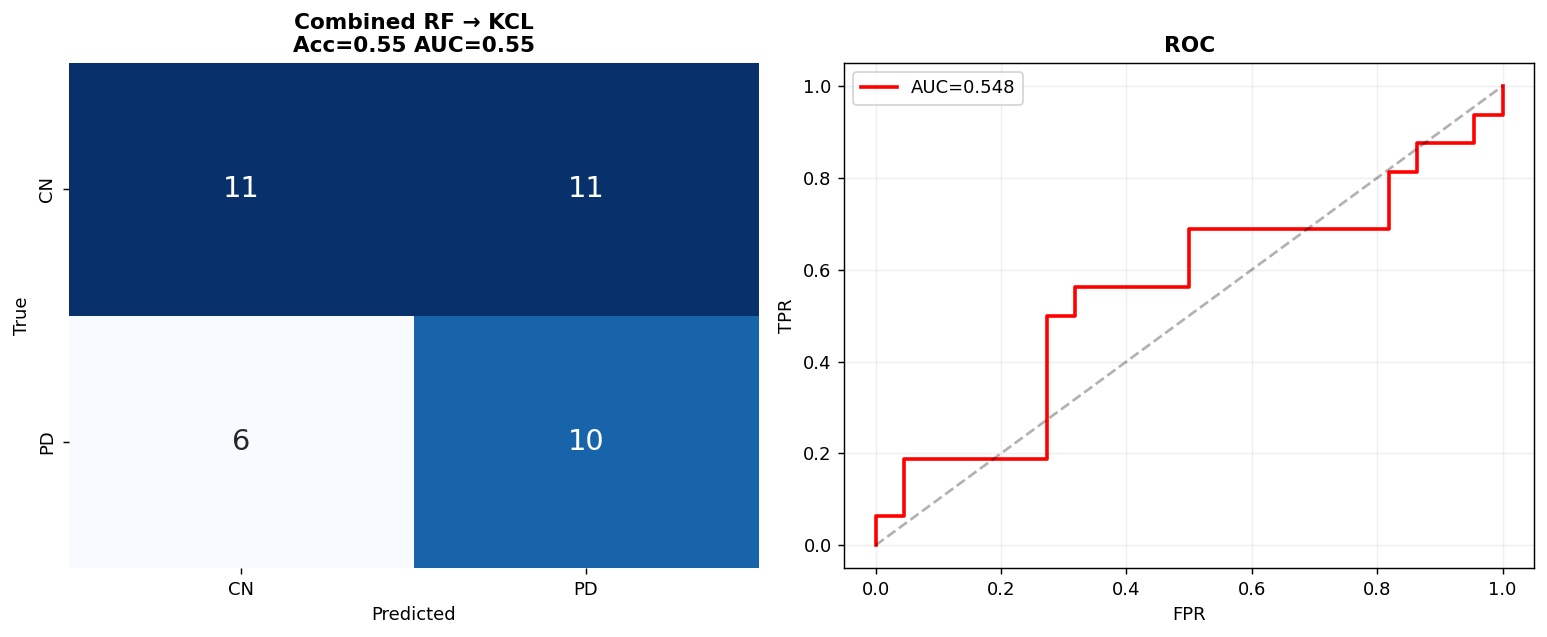

In [15]:
# ============================================================
# 4.3  Final KCL evaluation (all modalities)
# ============================================================
if kcl_combined is not None:
    print(f'KCL Cross-Corpus Evaluation')
    print(f'{"Modality":<15s} {"Acc":>7s} {"AUC":>7s}')
    print('─' * 30)
    
    for mod_name, r in all_cv_results.items():
        mod_feats = r['features']
        mod_scaler = r['scaler']
        mod_model = r['model']
        
        kcl_eval = kcl_combined.copy()
        for col in mod_feats:
            if col not in kcl_eval.columns:
                kcl_eval[col] = 0.0
        
        X_kcl = mod_scaler.transform(kcl_eval[mod_feats].fillna(0).values)
        y_kcl = kcl_eval['label'].values
        kcl_pred = mod_model.predict(X_kcl)
        kcl_prob = mod_model.predict_proba(X_kcl)[:, 1]
        
        acc = accuracy_score(y_kcl, kcl_pred)
        auc_val = roc_auc_score(y_kcl, kcl_prob) if len(np.unique(y_kcl)) > 1 else 0.5
        print(f'{mod_name:<15s} {acc:>7.3f} {auc_val:>7.3f}')
    
    # Detailed view for Combined model
    if 'Combined' in all_cv_results:
        r = all_cv_results['Combined']
        kcl_eval = kcl_combined.copy()
        for col in r['features']:
            if col not in kcl_eval.columns:
                kcl_eval[col] = 0.0
        
        X_kcl = r['scaler'].transform(kcl_eval[r['features']].fillna(0).values)
        y_kcl = kcl_eval['label'].values
        kcl_pred = r['model'].predict(X_kcl)
        kcl_prob = r['model'].predict_proba(X_kcl)[:, 1]
        acc = accuracy_score(y_kcl, kcl_pred)
        auc_val = roc_auc_score(y_kcl, kcl_prob) if len(np.unique(y_kcl)) > 1 else 0.5
        
        fig, axes = plt.subplots(1, 2, figsize=(12, 5))
        cm = confusion_matrix(y_kcl, kcl_pred)
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
                    xticklabels=['CN','PD'], yticklabels=['CN','PD'], cbar=False, annot_kws={'size':16})
        axes[0].set_title(f'Combined RF → KCL\nAcc={acc:.2f} AUC={auc_val:.2f}')
        axes[0].set_xlabel('Predicted'); axes[0].set_ylabel('True')
        
        fpr, tpr, _ = roc_curve(y_kcl, kcl_prob)
        axes[1].plot(fpr, tpr, 'r-', lw=2, label=f'AUC={auc_val:.3f}')
        axes[1].plot([0,1],[0,1],'k--',alpha=0.3); axes[1].set_xlabel('FPR'); axes[1].set_ylabel('TPR')
        axes[1].set_title('ROC'); axes[1].legend(); axes[1].grid(alpha=0.2)
        plt.tight_layout(); plt.savefig('multimodal_kcl_eval.png', dpi=150, bbox_inches='tight'); plt.show()
else:
    print('KCL combined data not available')